# Reusable Functions for Data Cleaning and EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def clean_data(df):
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Strip whitespace from string values and replace '?' with NaN
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'?': np.nan, 'nan': np.nan, 'None': np.nan})
        
    # Handle missing values: median for numeric, mode for categorical
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])
                
    # Remove duplicate rows
    df = df.drop_duplicates().reset_index(drop=True)
    return df

def show_info(df):
    print("Shape:", df.shape)
    print("\nInfo:")
    df.info()
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())

def plot_numeric(df, col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram of {col}")
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

def plot_categorical(df, col):
    plt.figure(figsize=(10, 4))
    if df[col].nunique() > 30:
        order = df[col].value_counts().head(30).index
    else:
        order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def check_outliers_iqr(df):
    outliers = []
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        outliers.append({'Column': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr, 'Outliers Count': count})
    return pd.DataFrame(outliers)

def plot_heatmap(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# Dataset 1: Loan Eligibility

In [2]:
df_loan = pd.read_csv('original/loan-train.csv')

In [3]:
show_info(df_loan)

Shape: (1614, 13)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 221.3 KB

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents

In [4]:
df_loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df_loan = clean_data(df_loan)
df_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1614.000000,1614.000000,1614.000000,1614.000000,1614.00000
mean,8746.304833,3658.722999,218.317224,291.078067,0.64684
std,6249.885122,3291.745935,132.785377,81.798158,0.47810
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,3675.250000,986.250000,112.000000,240.000000,0.00000
50%,7045.000000,2941.500000,180.000000,360.000000,1.00000
75%,13251.000000,5893.000000,322.000000,360.000000,1.00000
max,81000.000000,41667.000000,700.000000,480.000000,1.00000


In [6]:
check_outliers_iqr(df_loan)

,Column,Q1,Q3,IQR,Outliers Count
0,ApplicantIncome,3675.25,13251.0,9575.75,7
1,CoapplicantIncome,986.25,5893.0,4906.75,4
2,LoanAmount,112.00,322.0,210.00,2
3,Loan_Amount_Term,240.00,360.0,120.00,3
4,Credit_History,0.00,1.0,1.00,0


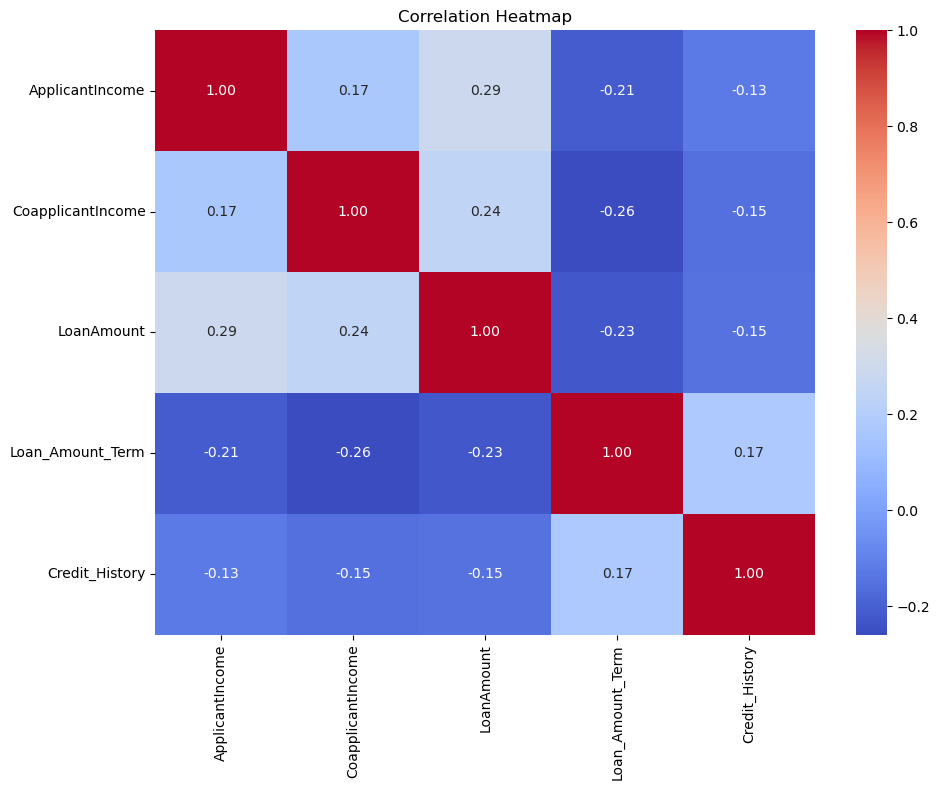

In [7]:
plot_heatmap(df_loan)

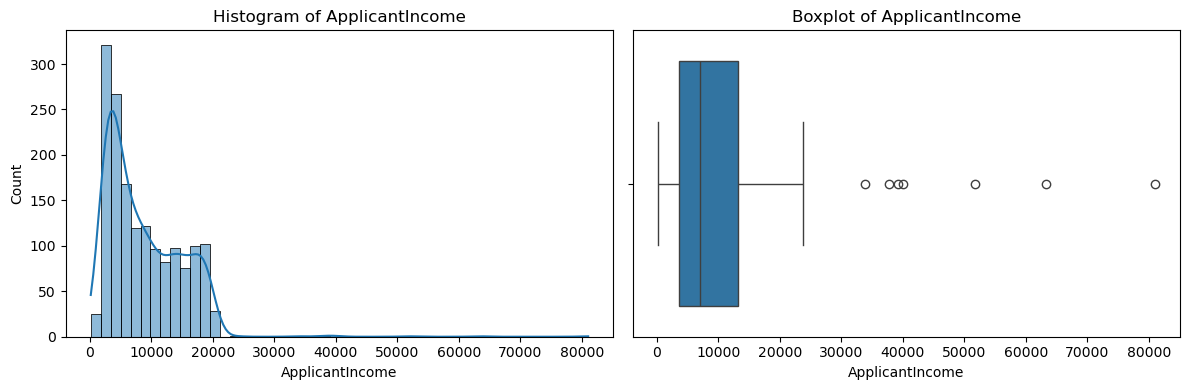

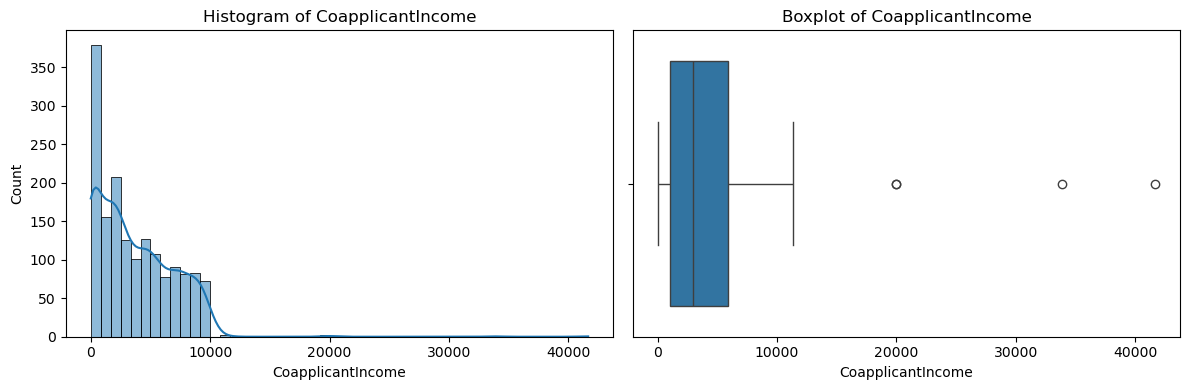

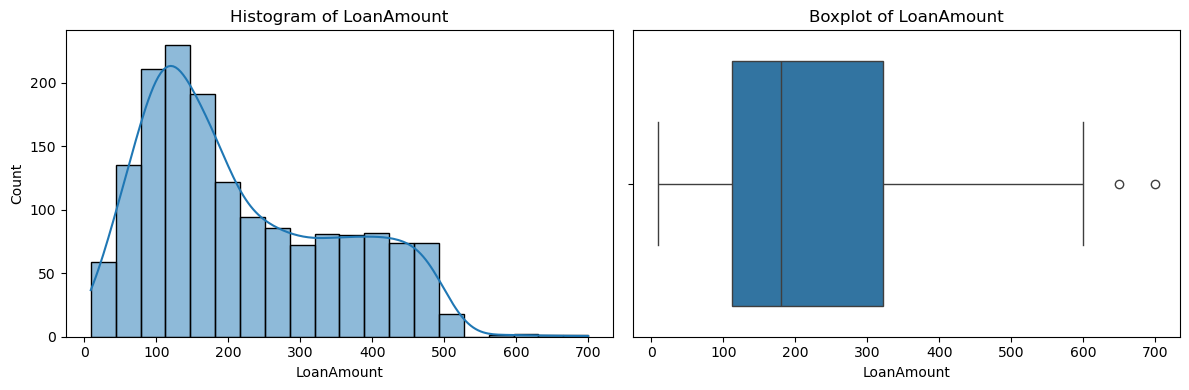

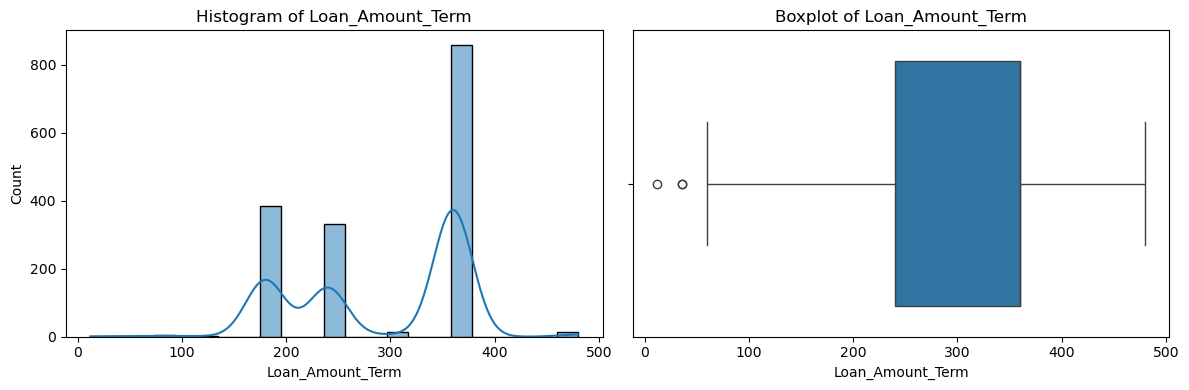

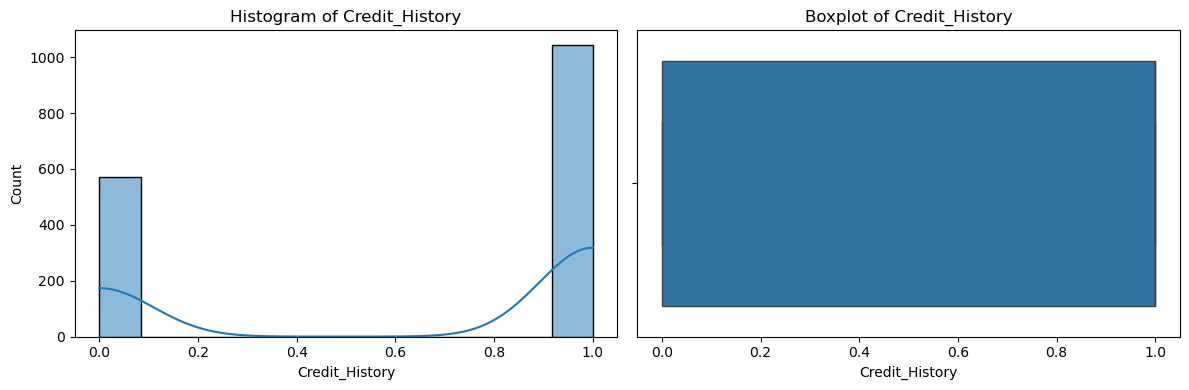

In [8]:
for col in df_loan.select_dtypes(include=['int64', 'float64']).columns:
    plot_numeric(df_loan, col)

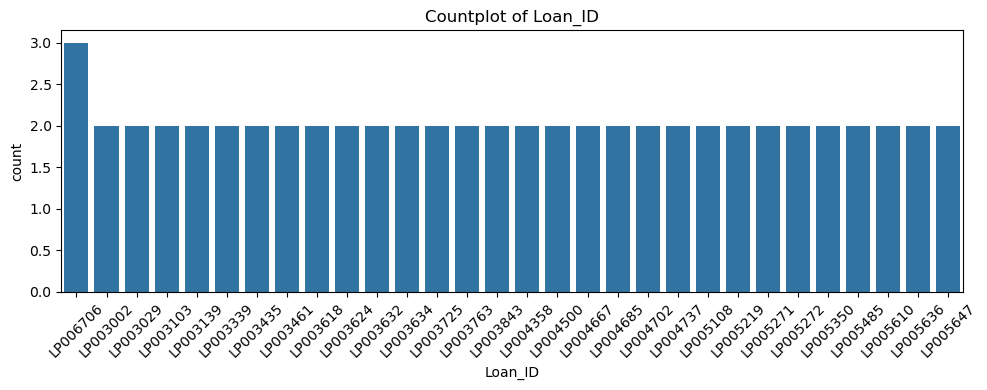

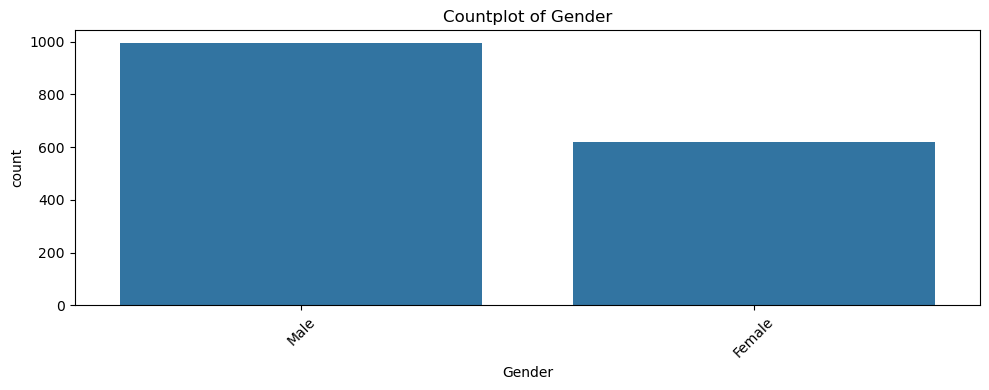

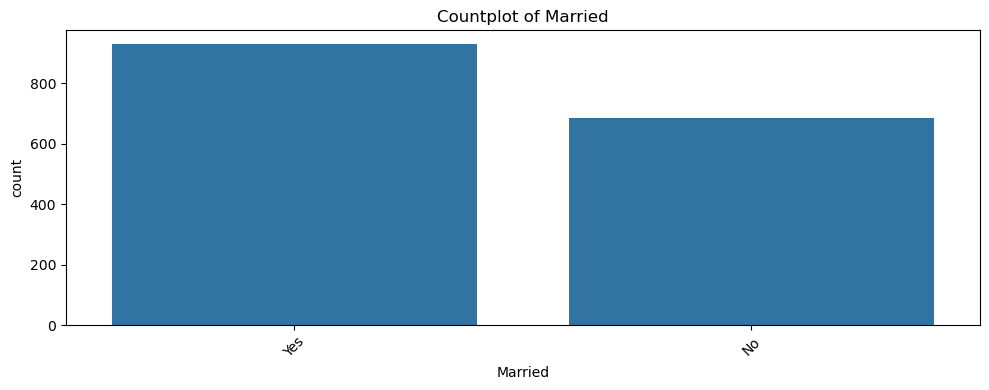

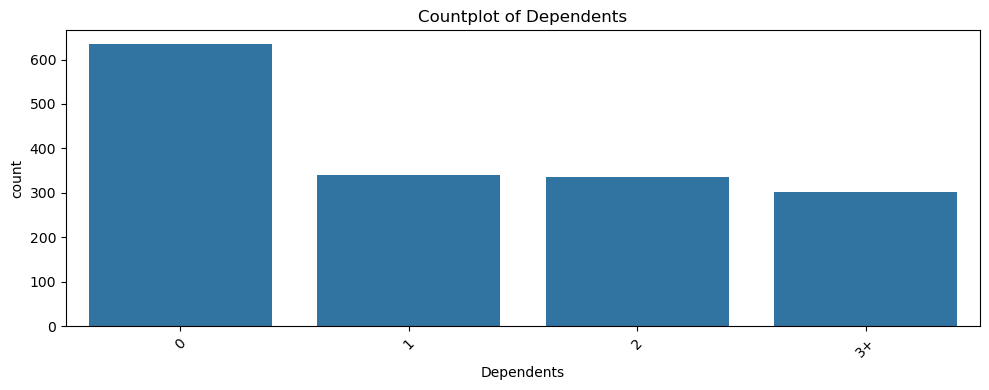

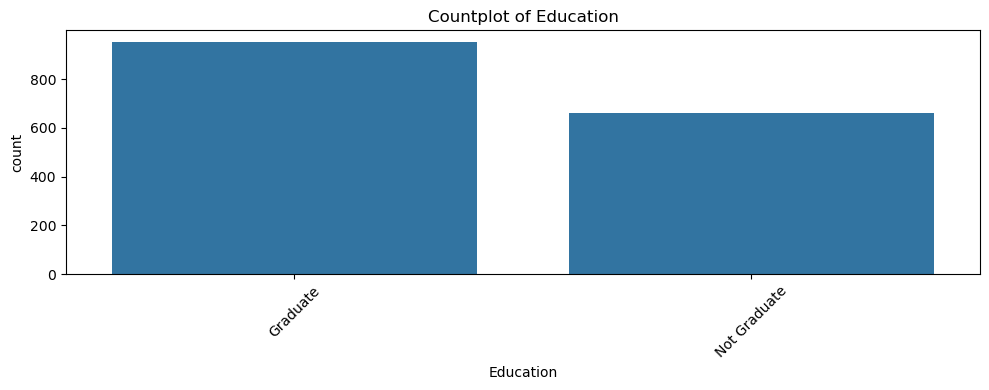

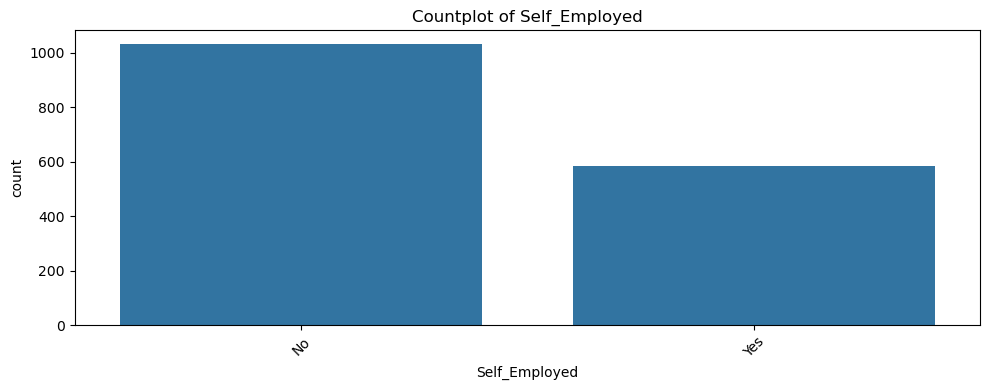

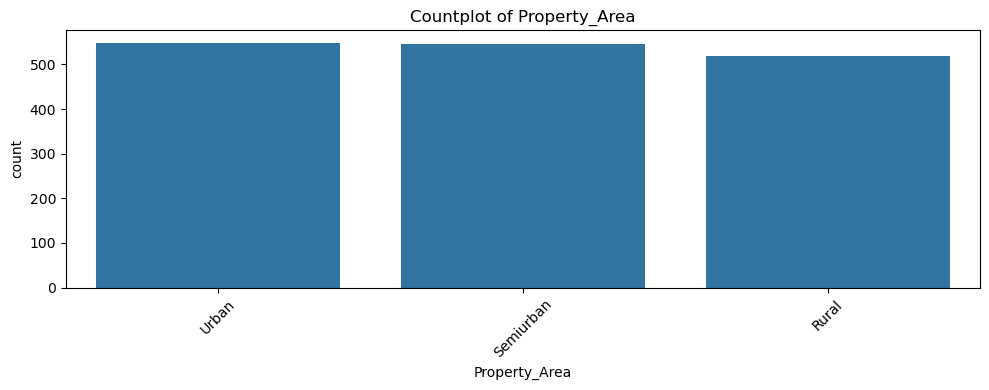

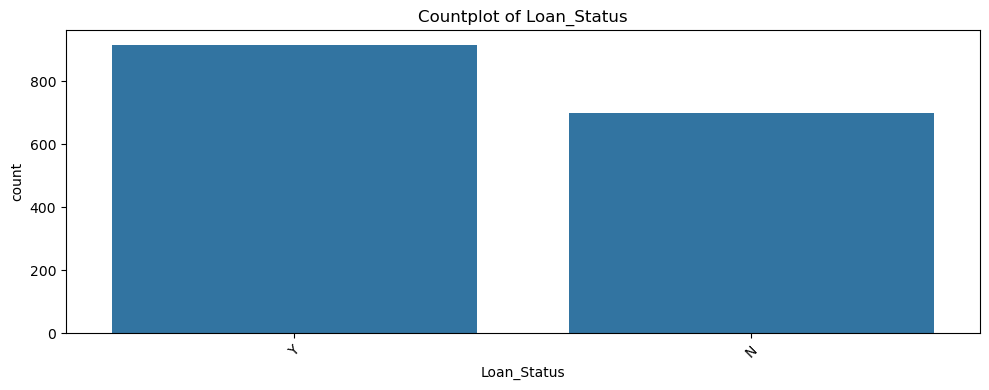

In [9]:
for col in df_loan.select_dtypes(include=['object']).columns:
    plot_categorical(df_loan, col)

In [10]:
df_loan.to_csv('cleaned/loan_cleaned.csv', index=False)

# Dataset 2: Adult Census Income

In [11]:
df_adult = pd.read_csv('original/adult.csv')

In [12]:
show_info(df_adult)

Shape: (48842, 15)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB

Missing Values:
age                0
workclass          0
fnlwgt             0
ed

In [13]:
df_adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [14]:
df_adult = clean_data(df_adult)
df_adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48789.000000,4.878900e+04,48789.000000,48789.000000,48789.000000,48789.000000
mean,38.653139,1.896697e+05,10.078809,1080.239829,87.597368,40.425895
std,13.708426,1.056182e+05,2.570072,7455.980728,403.213066,12.392856
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781400e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376080e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [15]:
check_outliers_iqr(df_adult)

,Column,Q1,Q3,IQR,Outliers Count
0,age,28.0,48.0,20.0,215
1,fnlwgt,117555.0,237608.0,120053.0,1453
2,educational-num,9.0,12.0,3.0,1787
3,capital-gain,0.0,0.0,0.0,4035
4,capital-loss,0.0,0.0,0.0,2282
5,hours-per-week,40.0,45.0,5.0,13486


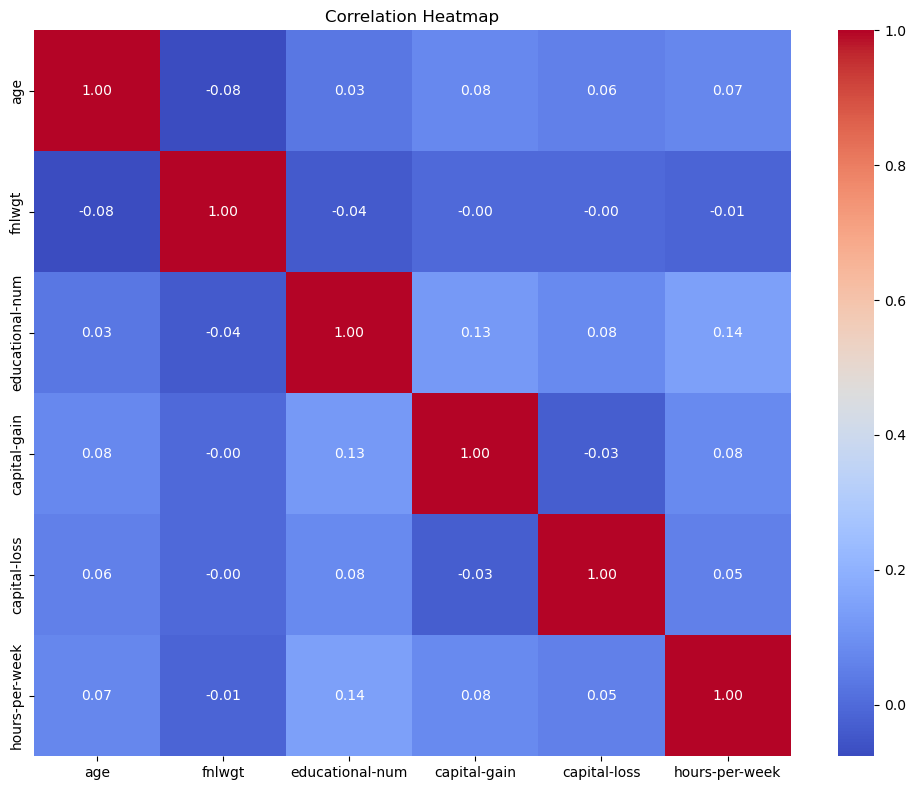

In [16]:
plot_heatmap(df_adult)

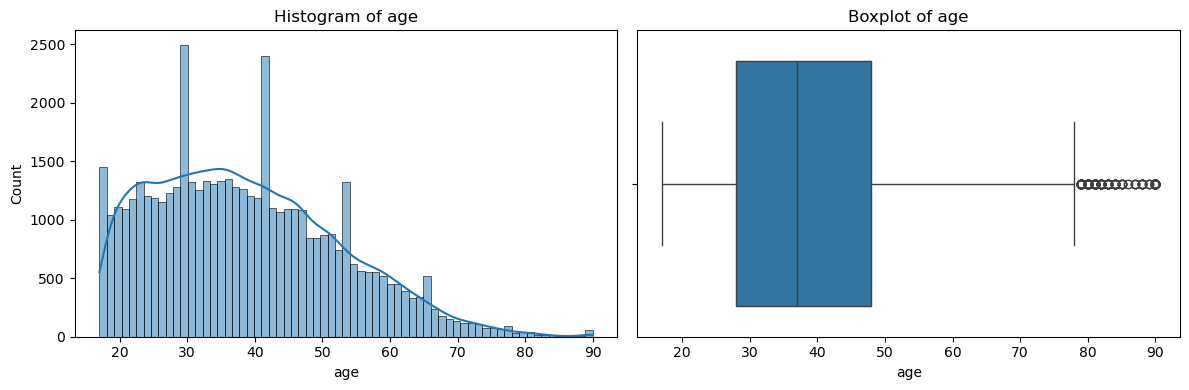

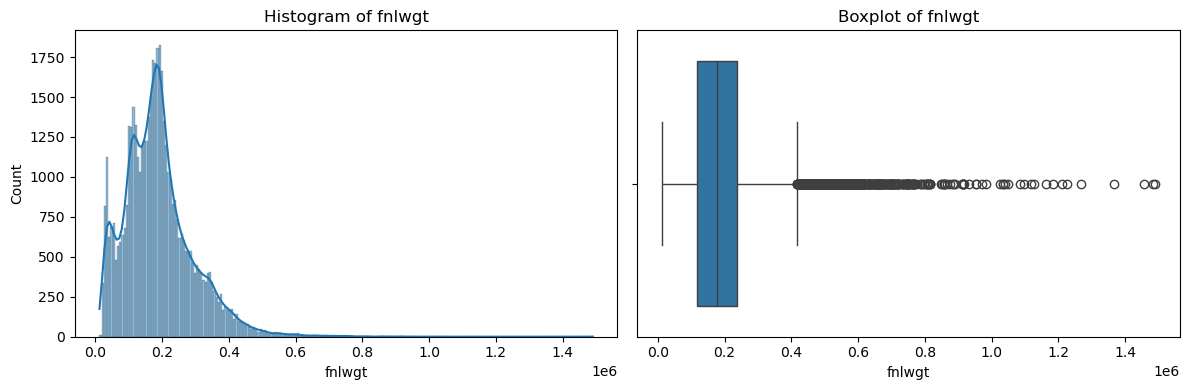

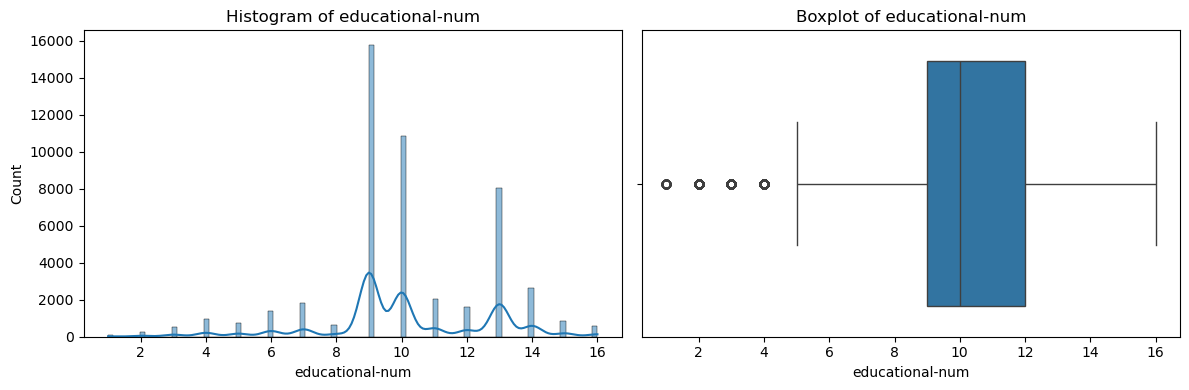

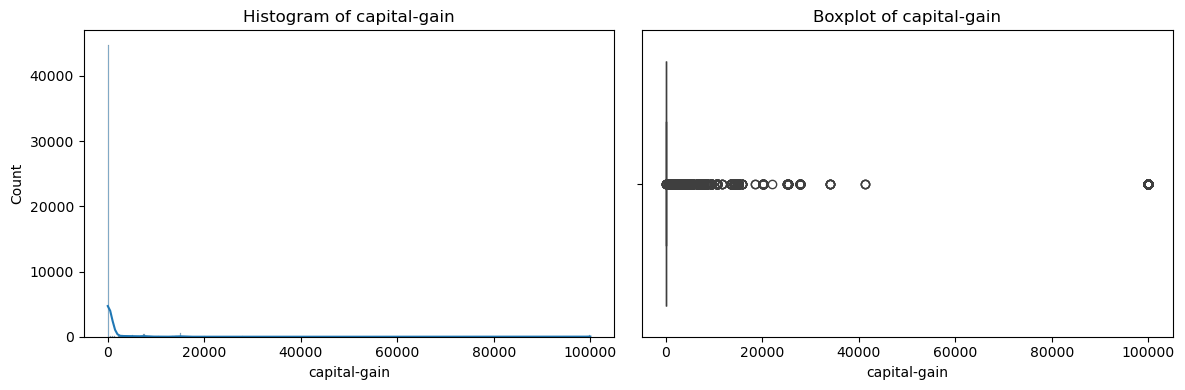

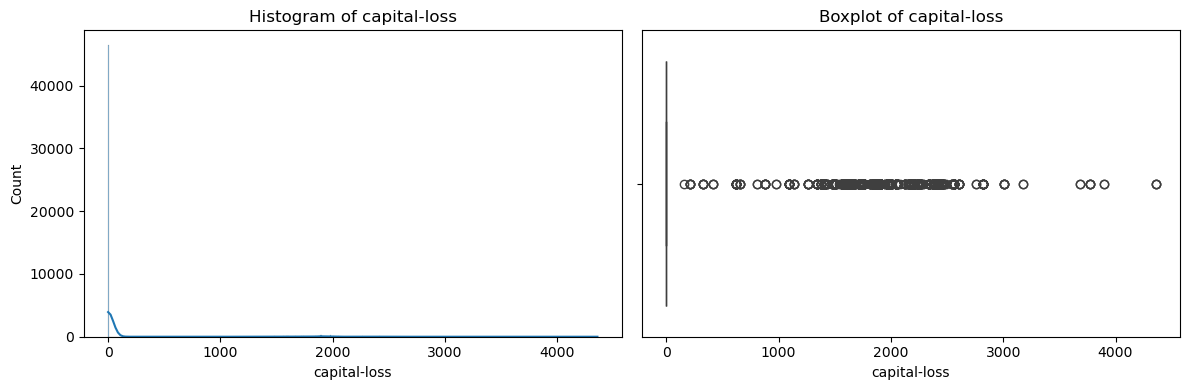

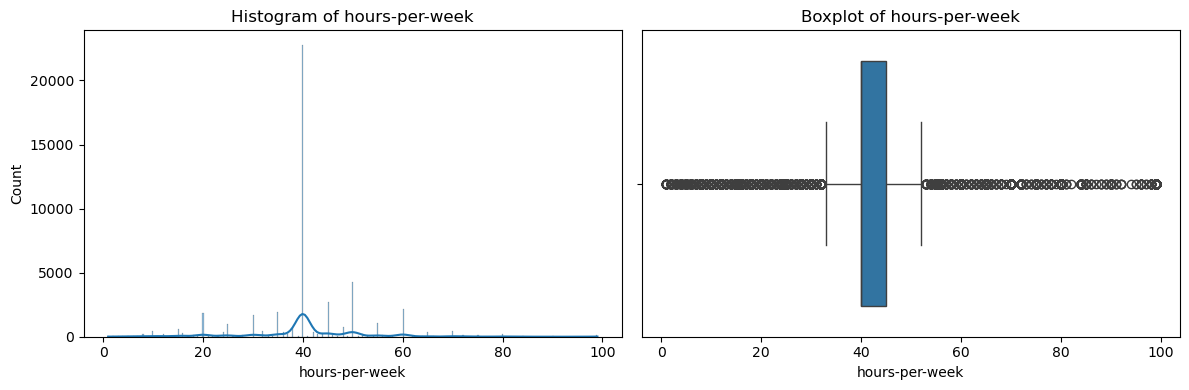

In [17]:
for col in df_adult.select_dtypes(include=['int64', 'float64']).columns:
    plot_numeric(df_adult, col)

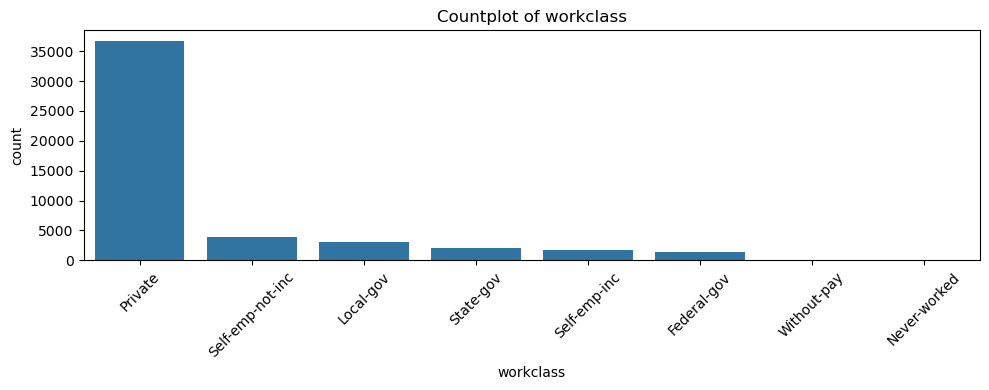

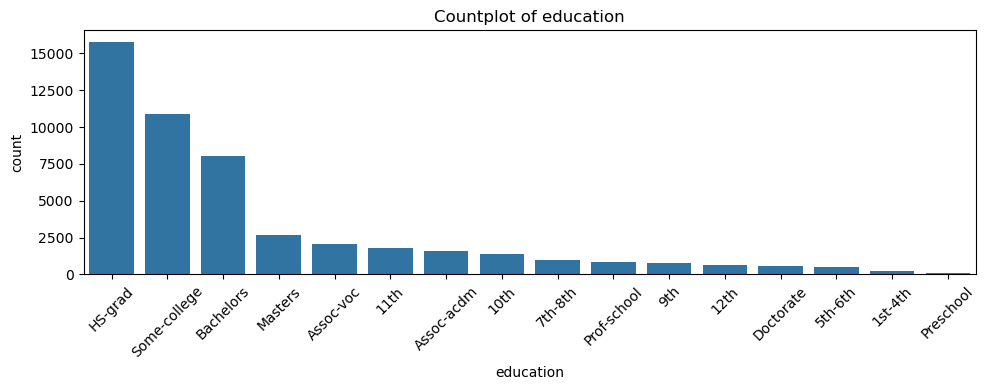

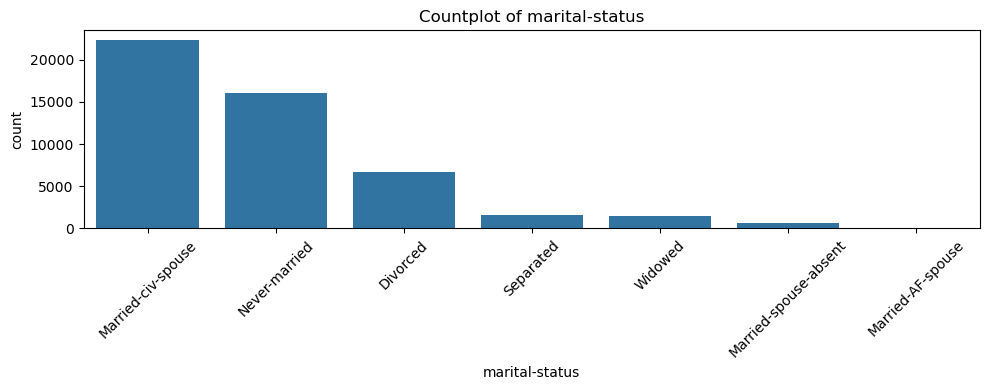

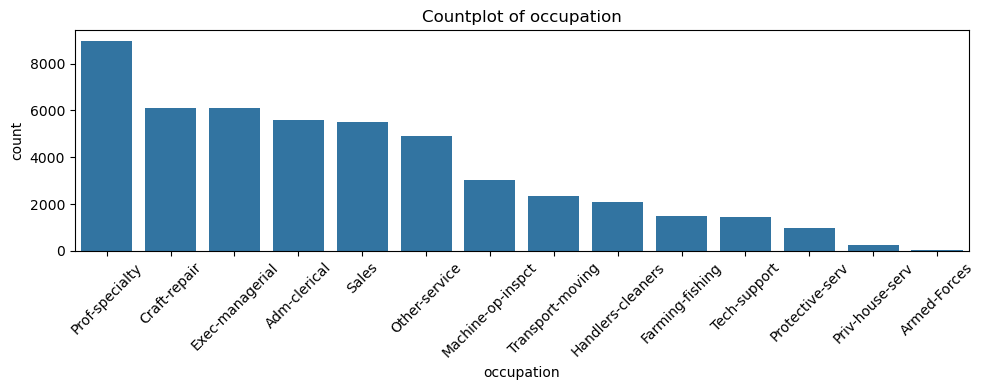

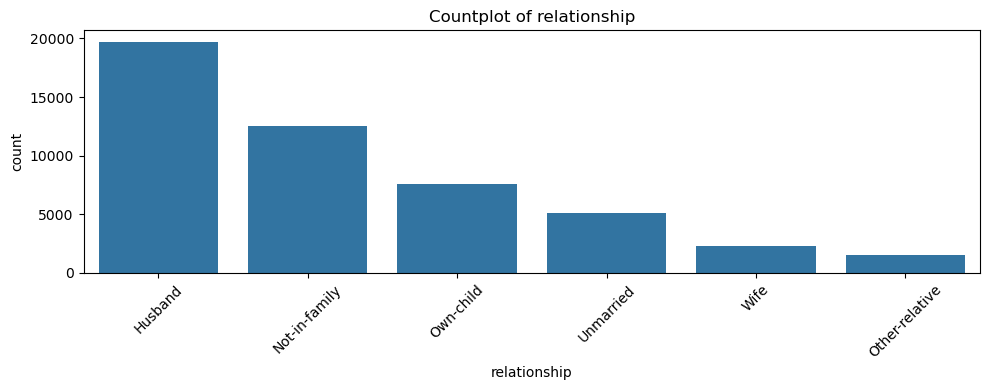

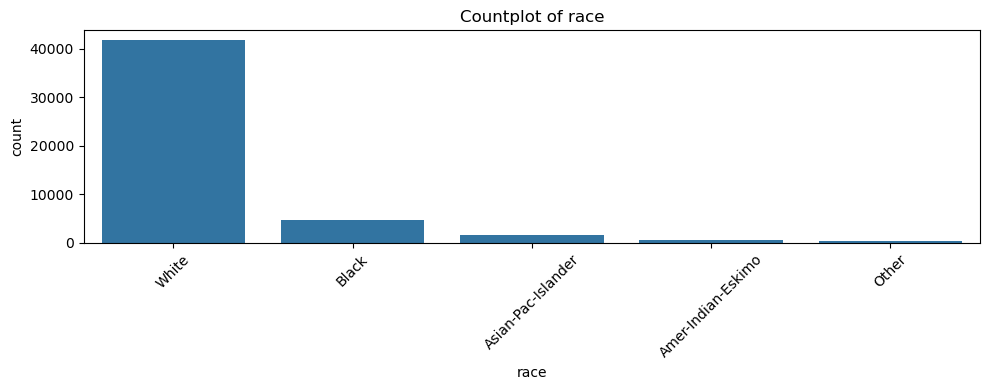

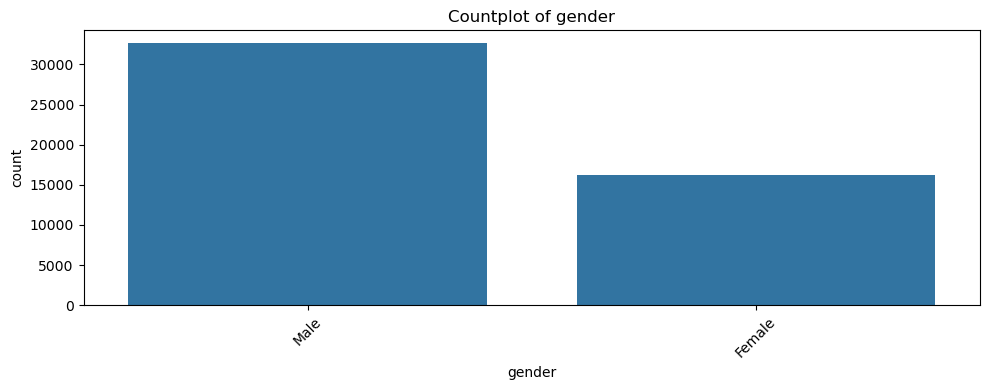

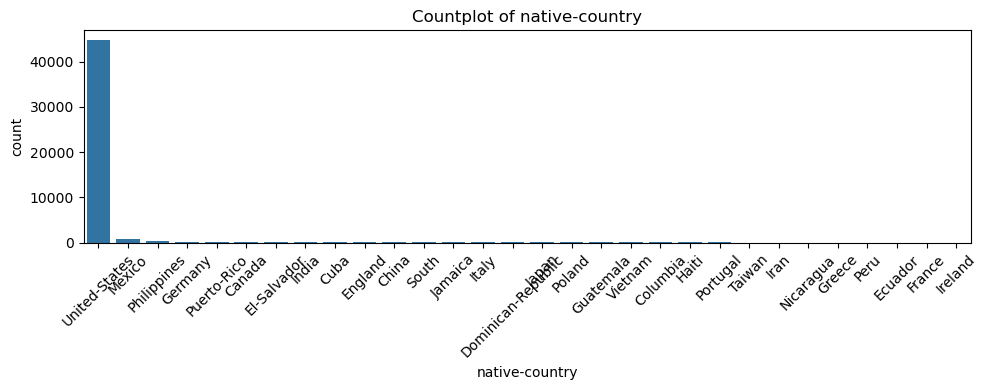

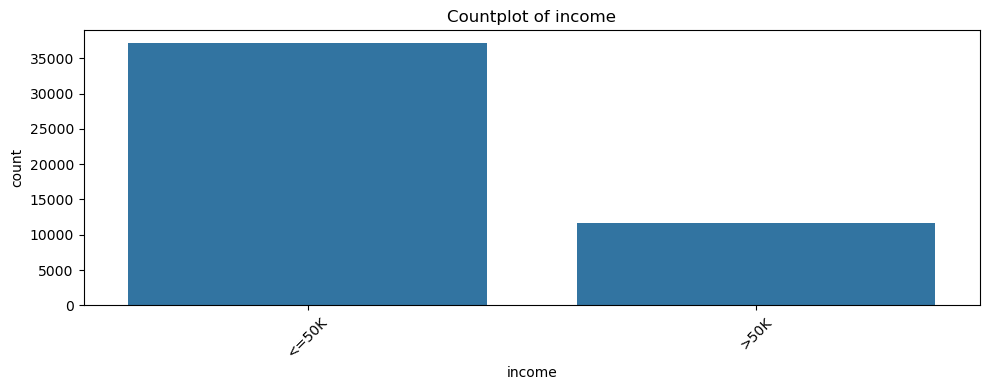

In [18]:
for col in df_adult.select_dtypes(include=['object']).columns:
    plot_categorical(df_adult, col)

In [19]:
df_adult.to_csv('cleaned/adult_cleaned.csv', index=False)

# Dataset 3: Hotel Booking

In [20]:
df_hotel = pd.read_csv('original/hotel_booking.csv')

In [21]:
show_info(df_hotel)

Shape: (119390, 36)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  

In [22]:
df_hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [23]:
df_hotel = clean_data(df_hotel)
df_hotel.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,76.744392,179.584496,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,105.904658,31.500968,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,179.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,179.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [24]:
check_outliers_iqr(df_hotel)

,Column,Q1,Q3,IQR,Outliers Count
0,is_canceled,0.00,1.0,1.00,0
1,lead_time,18.00,160.0,142.00,3005
2,arrival_date_year,2016.00,2017.0,1.00,0
3,arrival_date_week_number,16.00,38.0,22.00,0
4,arrival_date_day_of_month,8.00,23.0,15.00,0
5,stays_in_weekend_nights,0.00,2.0,2.00,265
6,stays_in_week_nights,1.00,3.0,2.00,3354
7,adults,2.00,2.0,0.00,29710
8,children,0.00,0.0,0.00,8590
9,babies,0.00,0.0,0.00,917


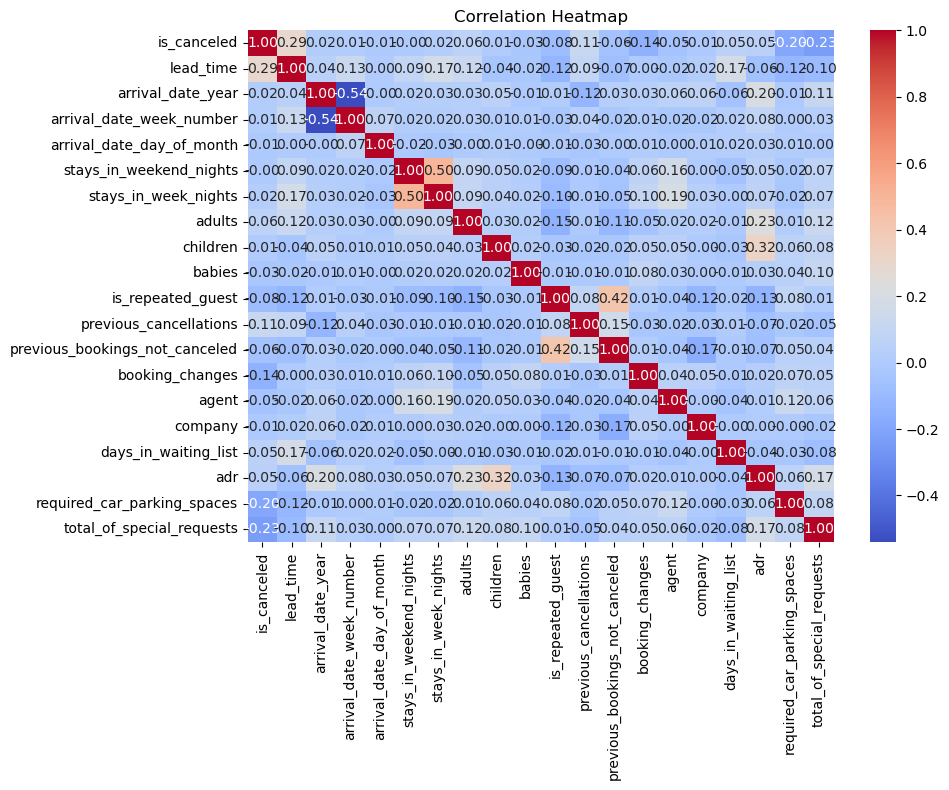

In [25]:
plot_heatmap(df_hotel)

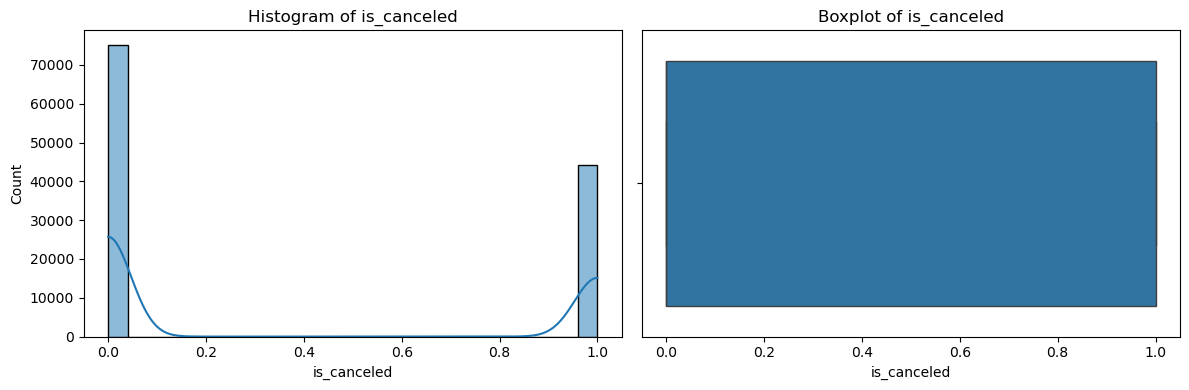

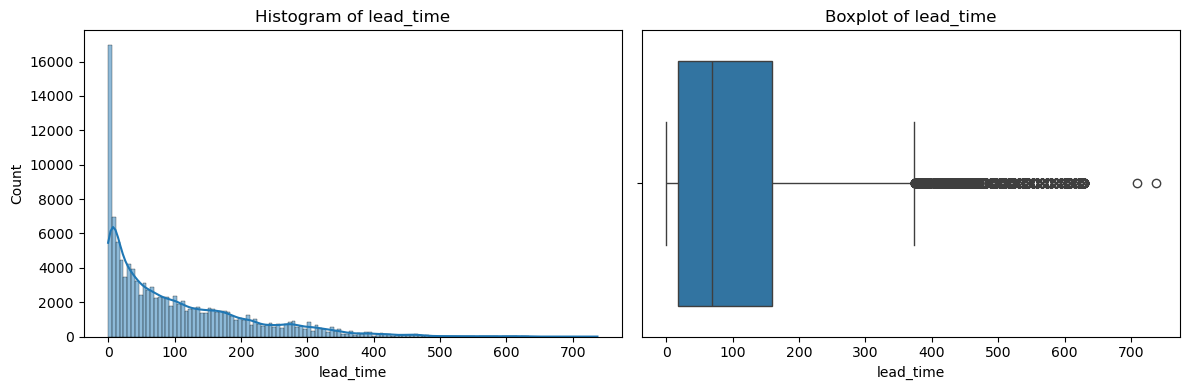

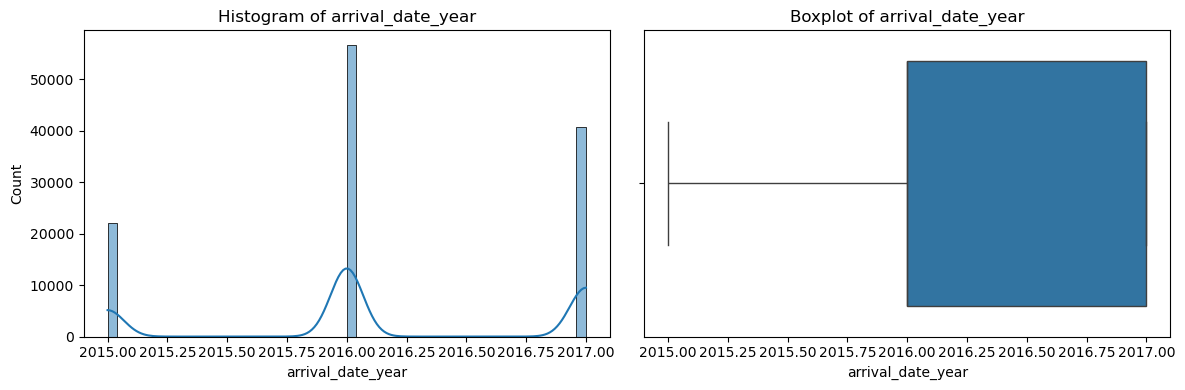

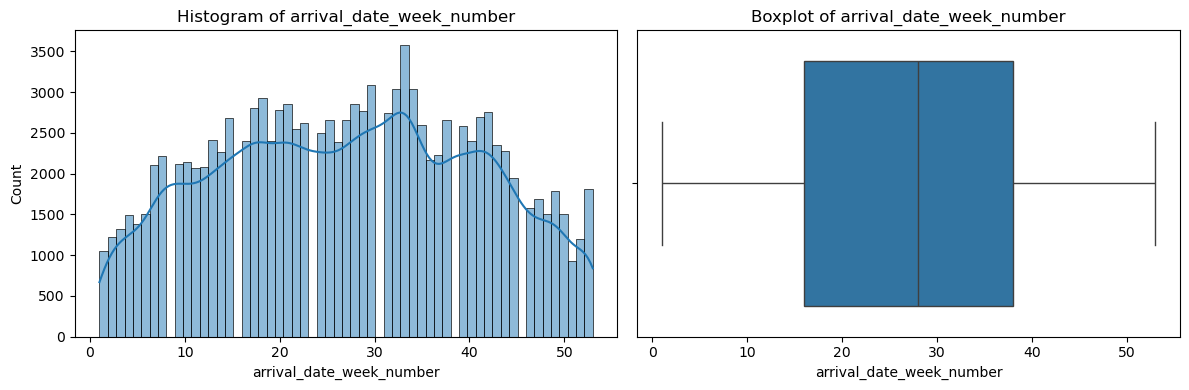

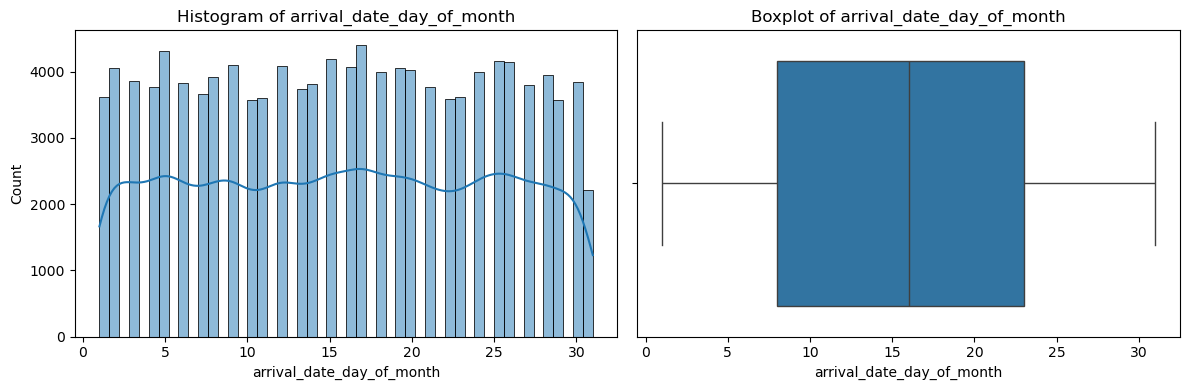

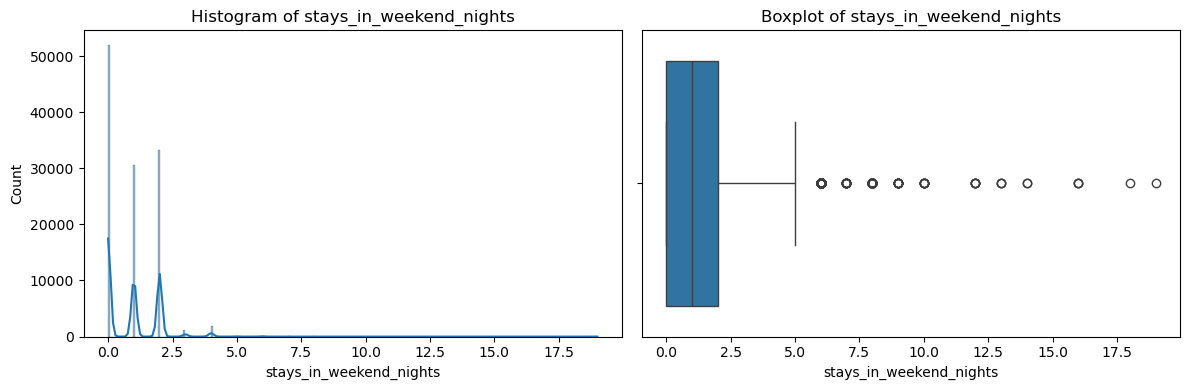

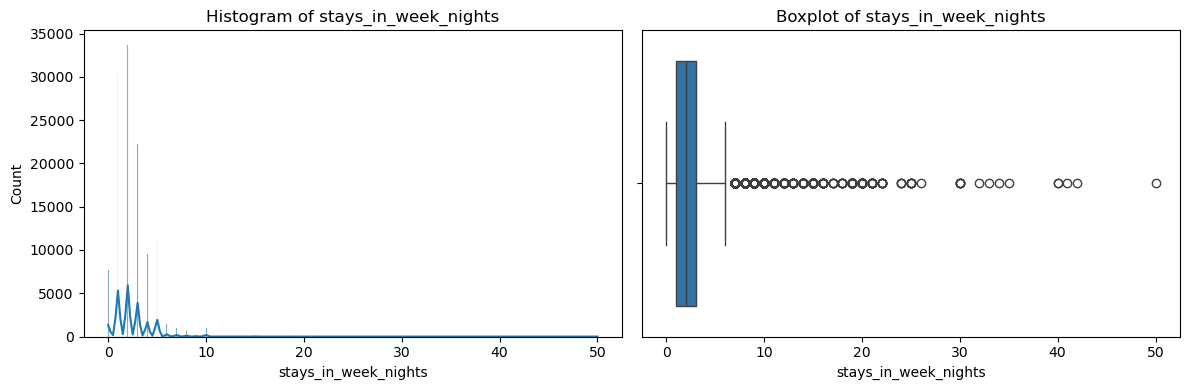

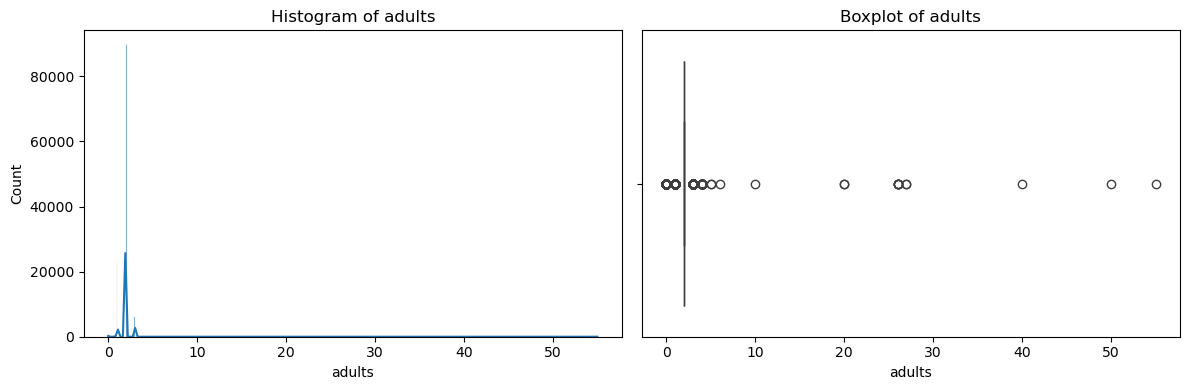

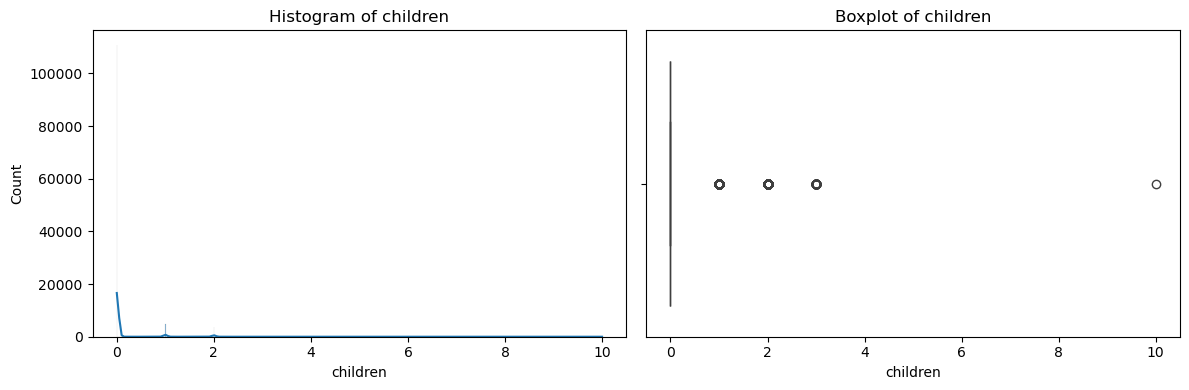

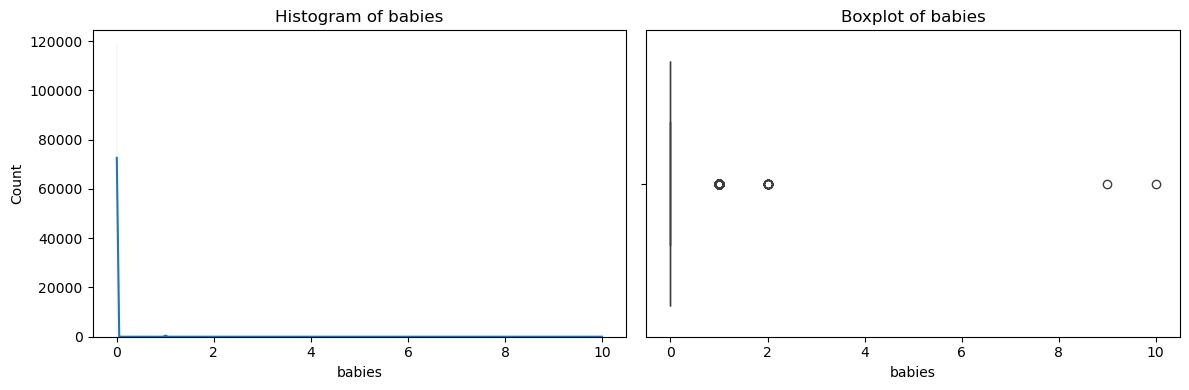

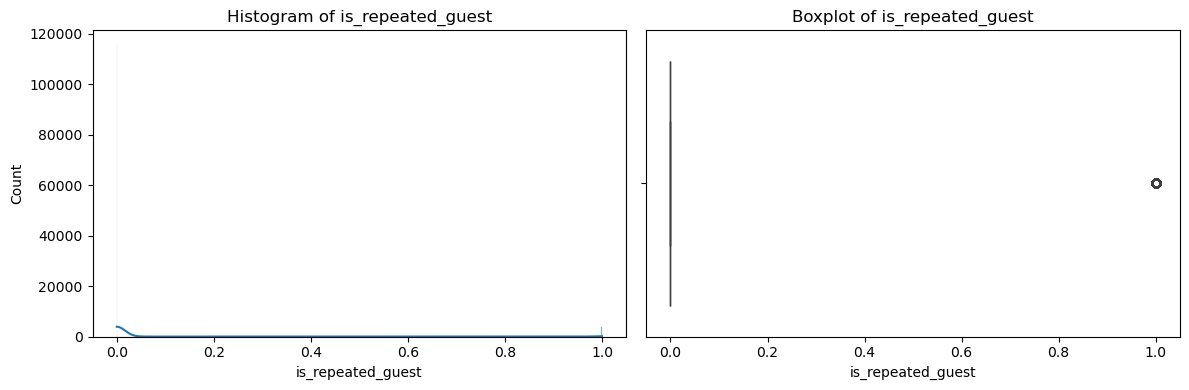

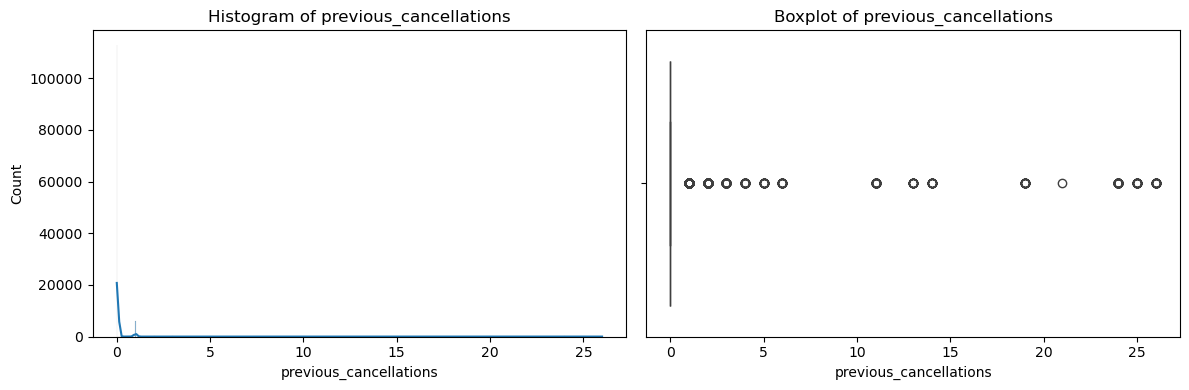

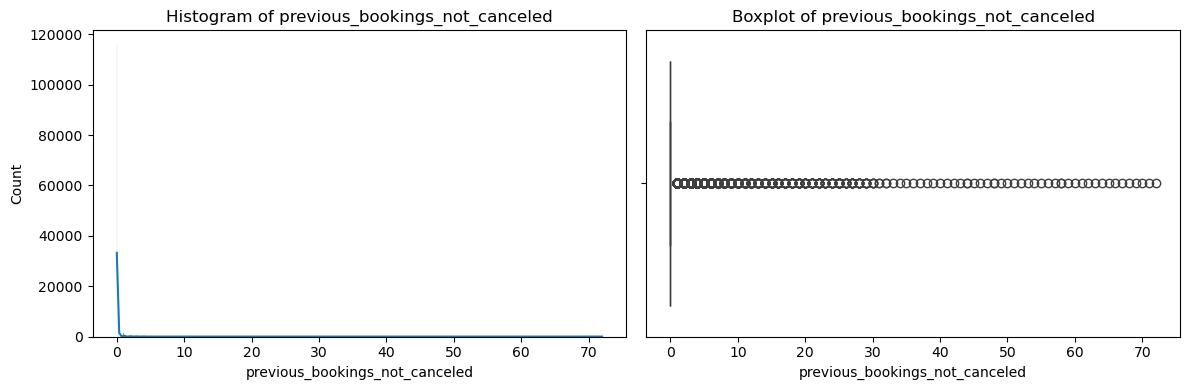

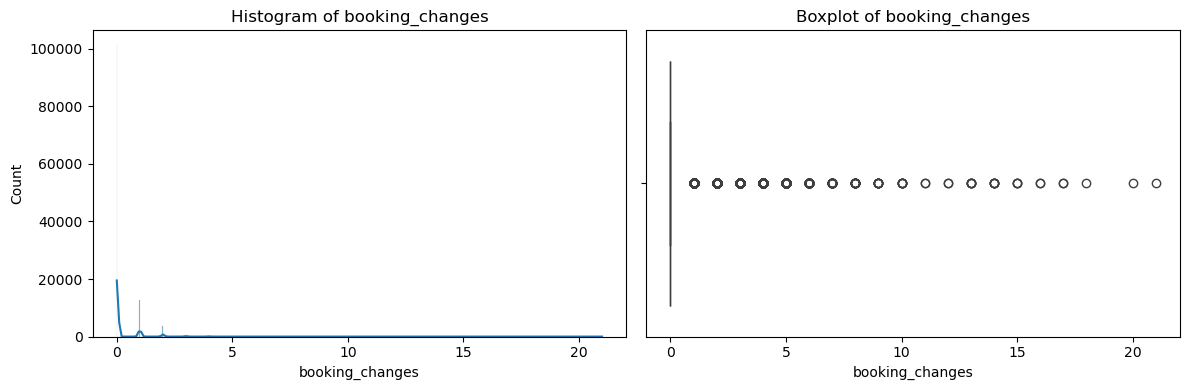

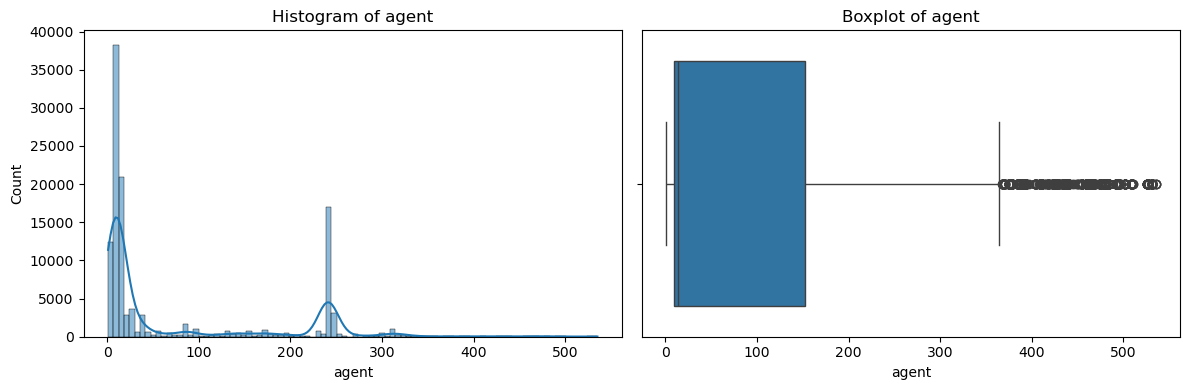

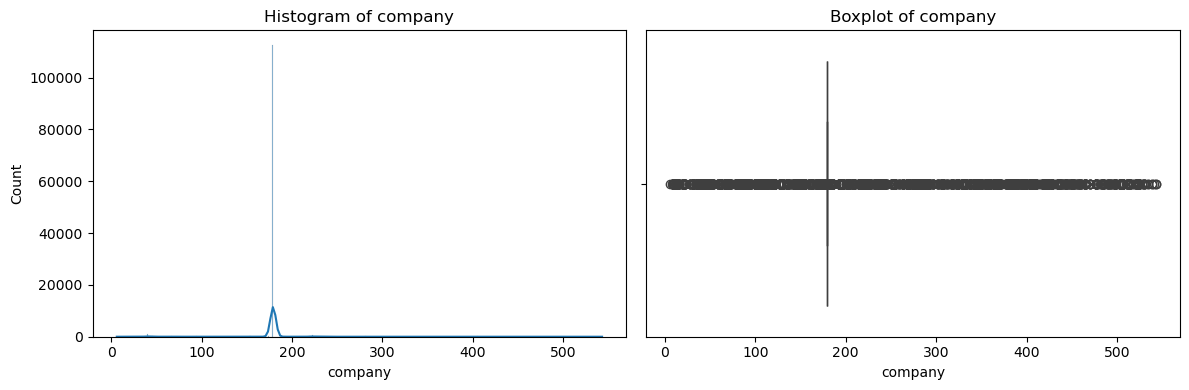

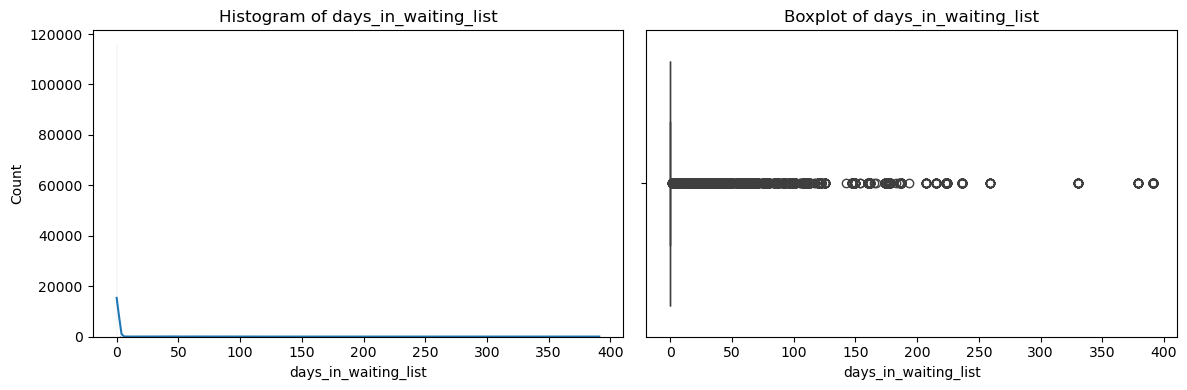

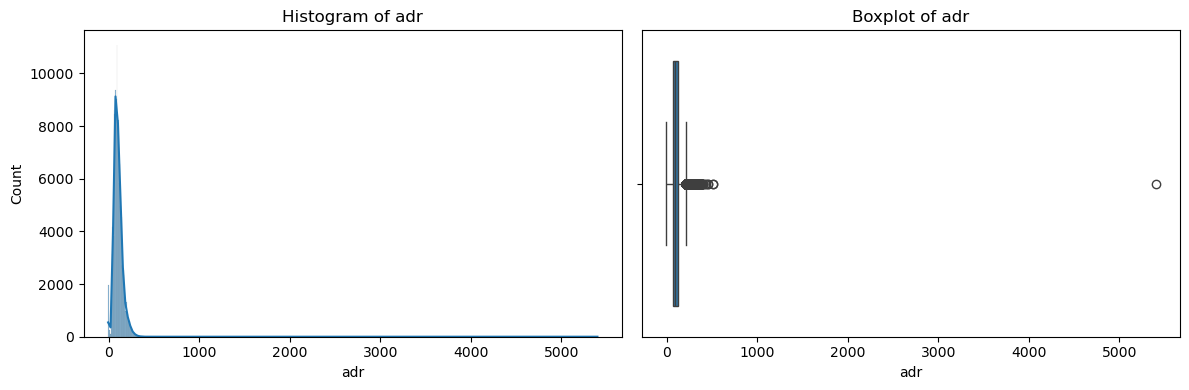

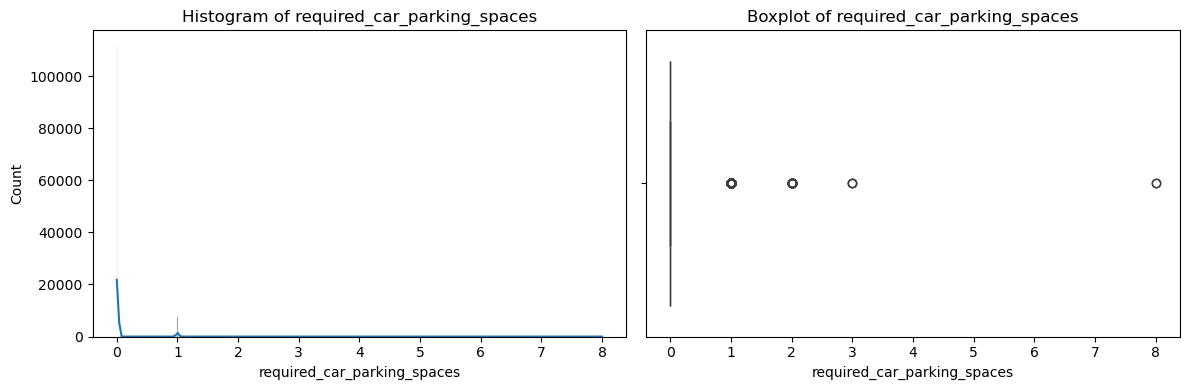

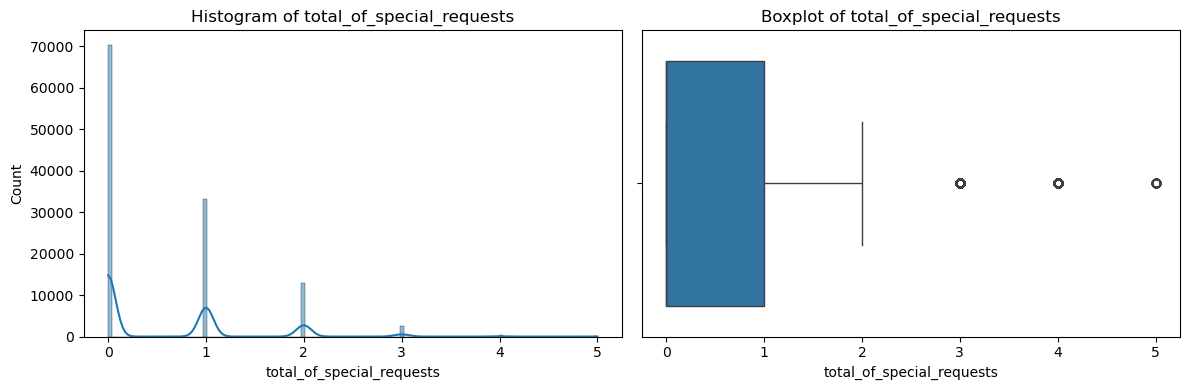

In [26]:
for col in df_hotel.select_dtypes(include=['int64', 'float64']).columns:
    plot_numeric(df_hotel, col)

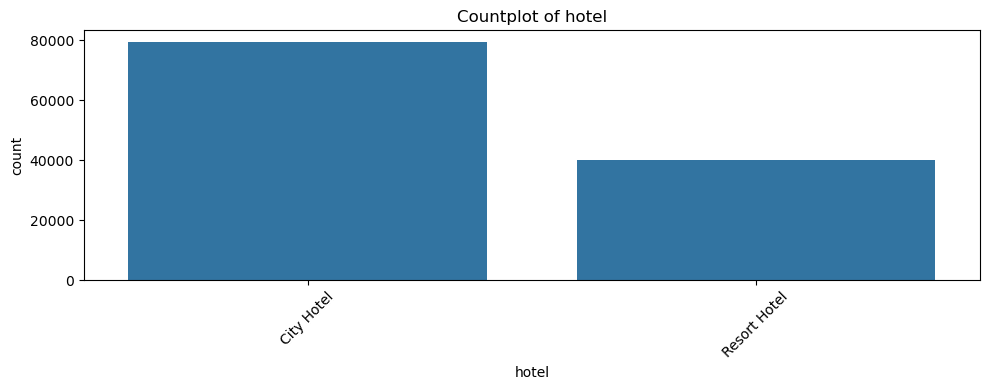

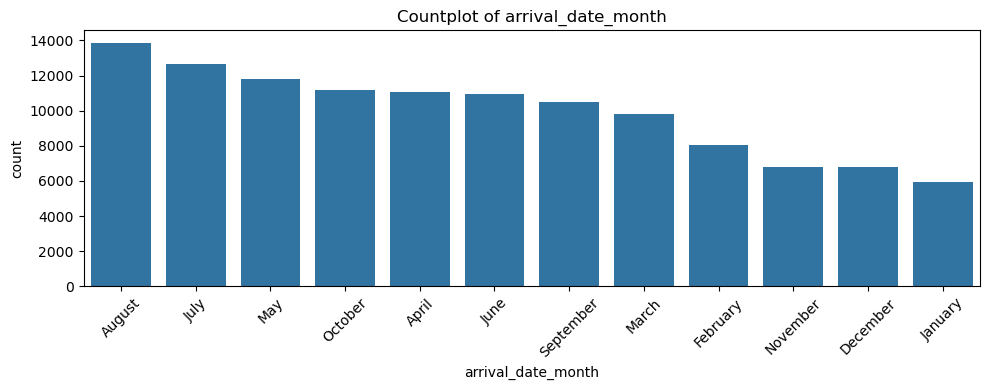

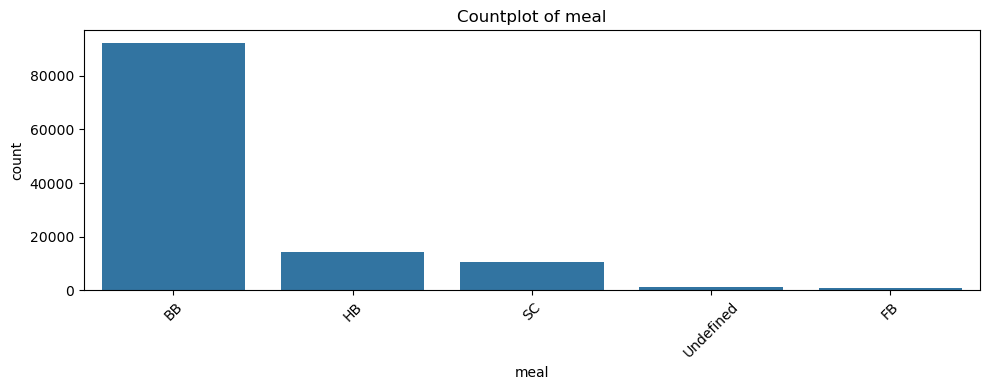

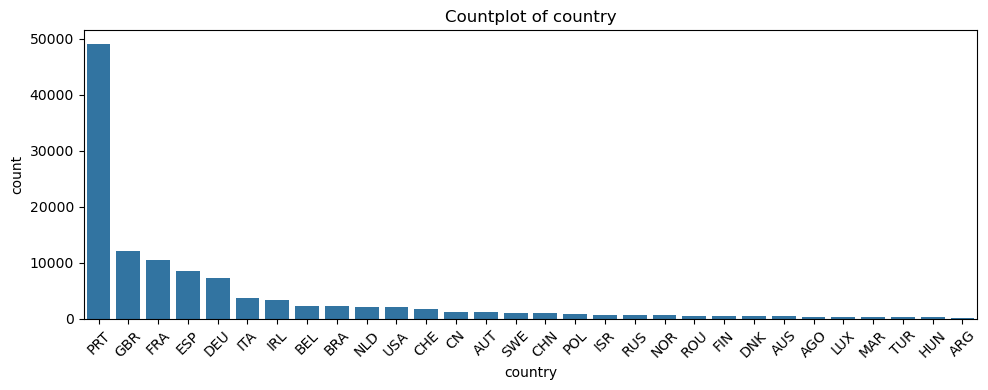

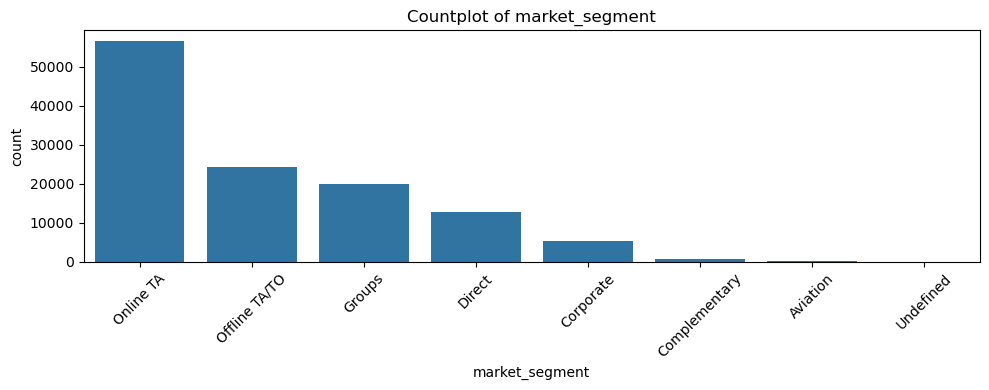

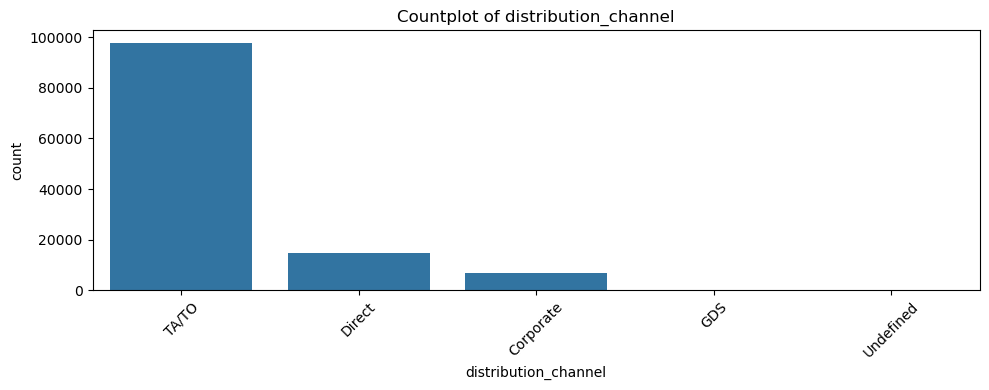

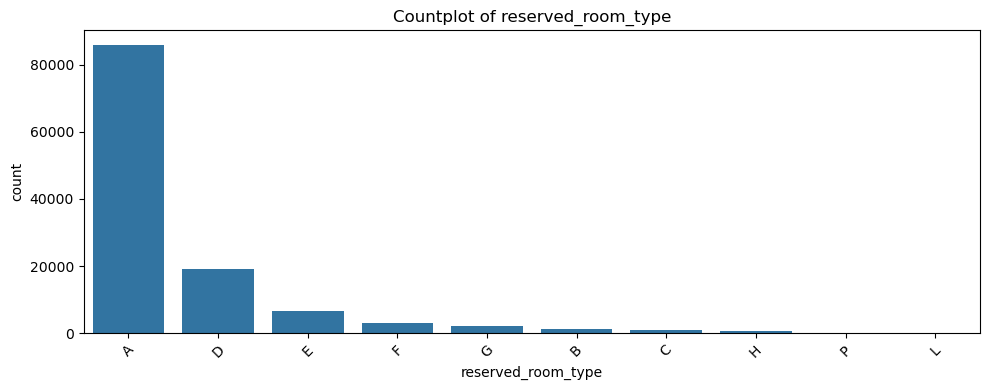

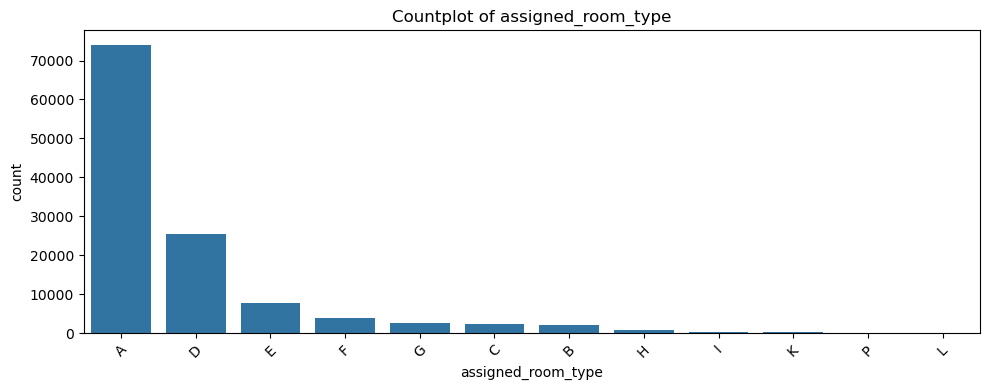

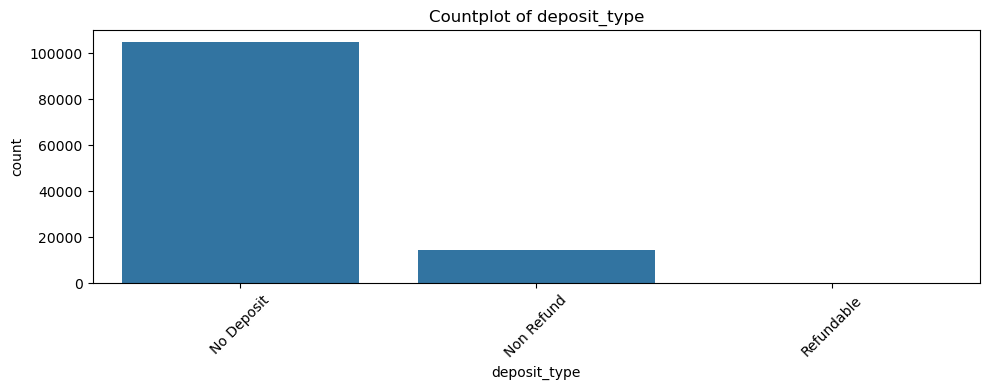

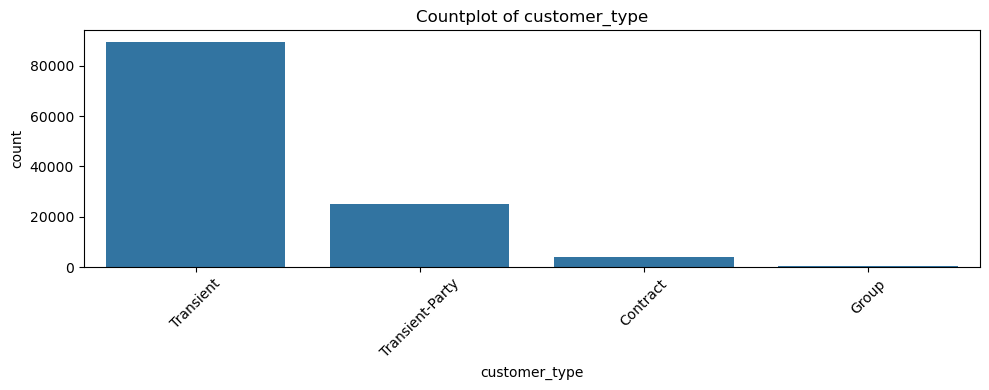

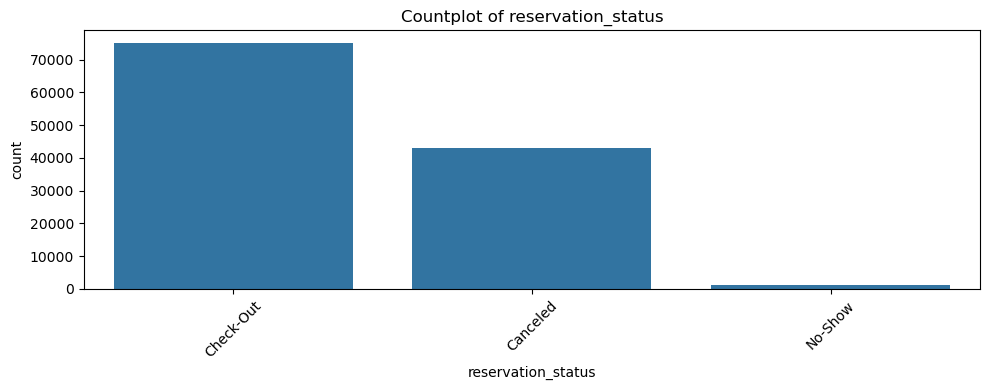

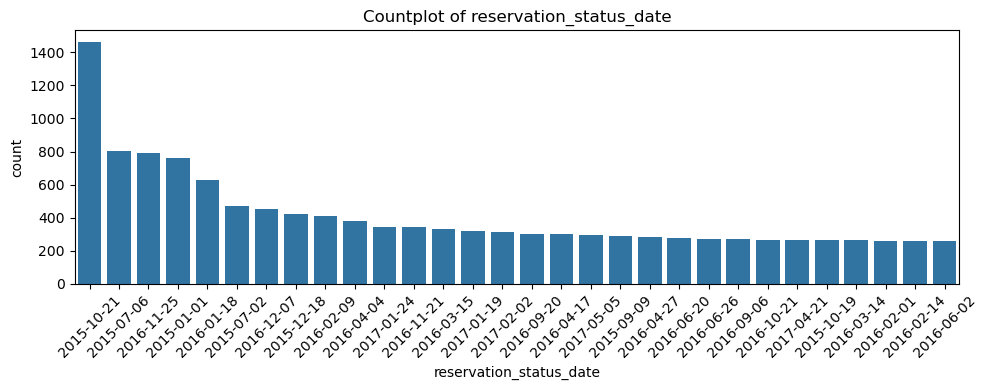

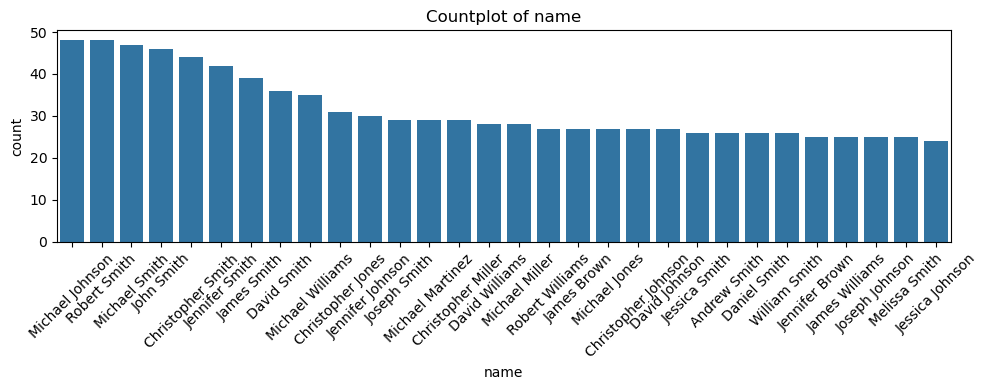

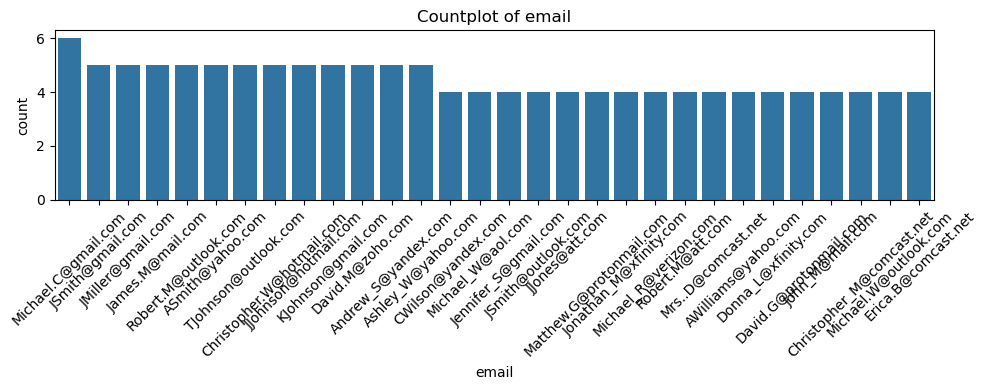

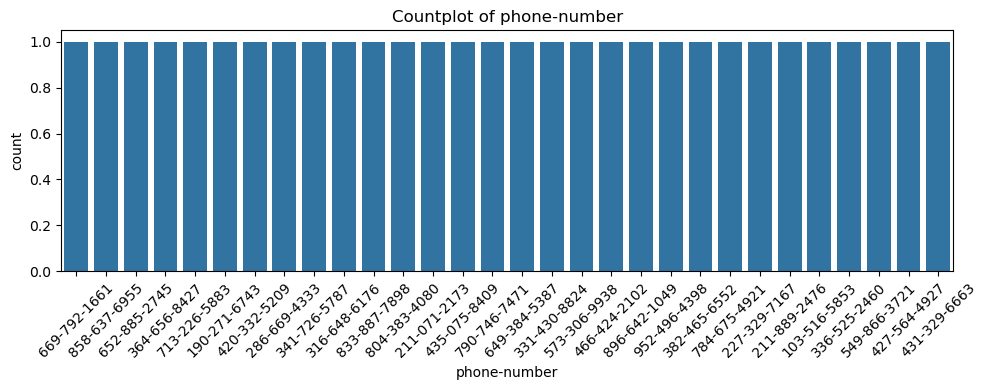

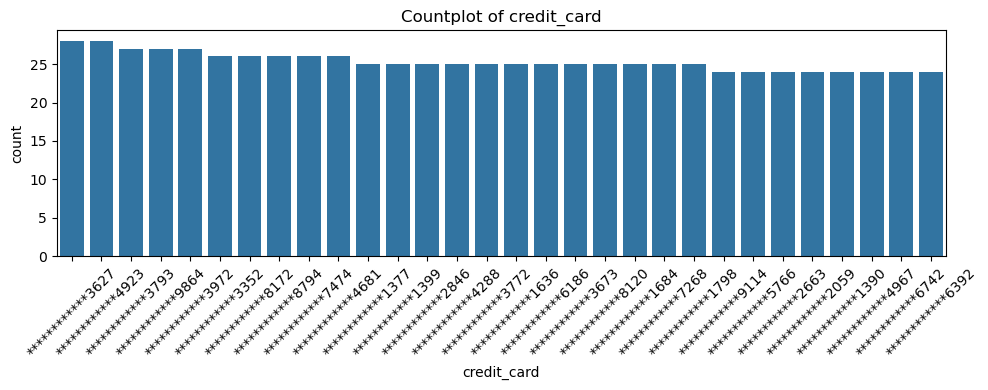

In [27]:
for col in df_hotel.select_dtypes(include=['object']).columns:
    plot_categorical(df_hotel, col)

In [28]:
df_hotel.to_csv('cleaned/hotel_booking_cleaned.csv', index=False)